In [151]:
#Import Necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [152]:
#loading data
df = pd.read_csv('D:\Data Science & Analytics Internship\Task 3 Customer Churn Prediction (Bank Customers)\Churn_Modelling.csv')

In [153]:
#Visualizing Data
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [154]:
#df.describe

In [155]:
#Checking missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [156]:
#Dropping unnecessary columns
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [157]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [158]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [159]:
#One-hot Encoding
#from sklearn.preprocessing import OneHotEncoder

In [160]:
#ohe = OneHotEncoder(sparse_output=False)
#categorical_columns = ['Geography', 'Gender']

# Fit and transform all categorical columns at once
#encoded = ohe.fit_transform(df[categorical_columns])

# Create new dataframe with proper column names
#one_hot_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(categorical_columns))

#print(encoded)

In [161]:
#one_hot_df = pd.get_dummies(df[['Geography', 'Gender']])
#print(one_hot_df)

In [162]:
#Encode Gender (Binary)
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
#One-Hot Encoding
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

In [163]:
#Training, testing and evaluating model

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [164]:
#Targetted Column
X = df.drop('Exited', axis = 1)
y = df['Exited']

In [165]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [166]:
model = RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

In [167]:
y_pred = model.predict(X_test)

In [168]:
#Displaying

print("Accuracy Score:", (accuracy_score(y_test, y_pred))*100,'%')
print("\nConfusion Matrix:", confusion_matrix(y_test,y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 87.05000000000001 %

Confusion Matrix: [[1554   53]
 [ 206  187]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.78      0.48      0.59       393

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [169]:
#Feature importance tells us which customer details matter most when predicting churn.
#Which columns did you use the most while making decisions?
#Get importance values from the model

importances = model.feature_importances_
features = X.columns

feature_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_df.head()


,Feature,Importance
2,Age,0.236955
8,EstimatedSalary,0.146188
0,CreditScore,0.142076
4,Balance,0.141416
5,NumOfProducts,0.131854


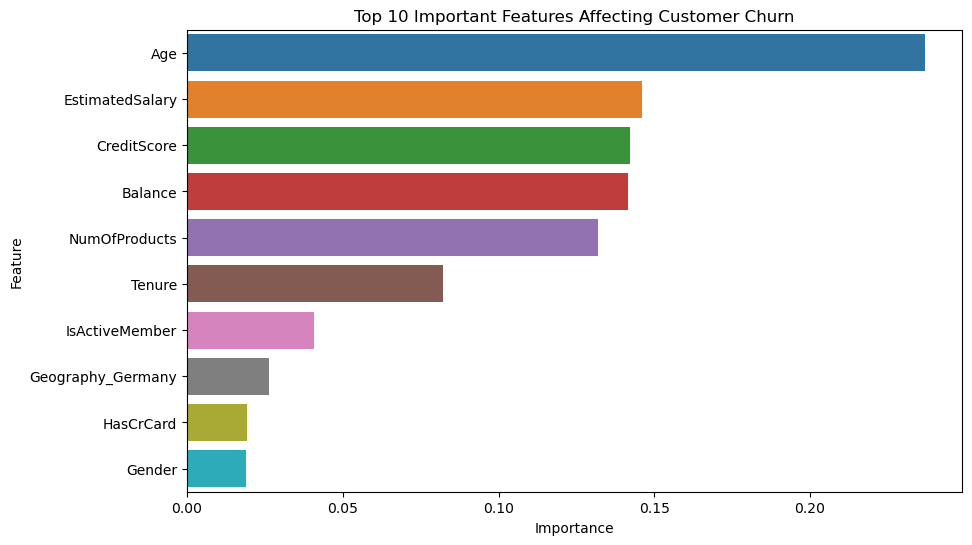

In [170]:
#Visualize top 10 features affecting customer churn

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(10))
plt.title("Top 10 Important Features Affecting Customer Churn")
plt.show()